In [20]:
!pip install pandas matplotlib pillow

Defaulting to user installation because normal site-packages is not writeable


In [21]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams['figure.figsize'] = (12, 6)


In [22]:
TRAIN_DIR = 'ASL_Alphabet_Dataset/asl_alphabet_train'
TEST_DIR = 'ASL_Alphabet_Dataset/asl_alphabet_test_2'

VALID_CLASSES = [chr(i) for i in range(ord('A'), ord('Z') + 1)]
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

print('TRAIN_DIR =', TRAIN_DIR)
print('TEST_DIR  =', TEST_DIR)
print('N.º de classes esperadas =', len(VALID_CLASSES))


TRAIN_DIR = ASL_Alphabet_Dataset/asl_alphabet_train
TEST_DIR  = ASL_Alphabet_Dataset/asl_alphabet_test_2
N.º de classes esperadas = 26


In [23]:
def list_images_in_class_folder(class_dir):
    class_path = Path(class_dir)
    if not class_path.exists() or not class_path.is_dir():
        return []
    return sorted([
        p for p in class_path.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ])


def scan_dataset(root_dir, valid_classes):
    root = Path(root_dir)
    rows = []

    if not root.exists():
        raise FileNotFoundError(f'Diretório não encontrado: {root_dir}')

    for cls in valid_classes:
        class_dir = root / cls
        image_files = list_images_in_class_folder(class_dir)

        for img_path in image_files:
            width = None
            height = None
            mode = None
            broken = False

            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                    mode = img.mode
            except Exception:
                broken = True

            rows.append({
                'dataset': root.name,
                'class': cls,
                'filename': img_path.name,
                'filepath': str(img_path),
                'ext': img_path.suffix.lower(),
                'width': width,
                'height': height,
                'mode': mode,
                'broken': broken
            })

    df = pd.DataFrame(rows)
    if df.empty:
        df = pd.DataFrame(columns=[
            'dataset', 'class', 'filename', 'filepath', 'ext',
            'width', 'height', 'mode', 'broken'
        ])
    return df


def count_by_class(df, valid_classes, dataset_name):
    counts = df.groupby('class').size().reindex(valid_classes, fill_value=0)
    out = counts.reset_index()
    out.columns = ['class', 'count']
    out['dataset'] = dataset_name
    return out


def balance_summary(count_df):
    counts = count_df['count'].values
    total = int(counts.sum())
    n_classes = len(counts)
    mean = float(np.mean(counts)) if n_classes else 0
    std = float(np.std(counts)) if n_classes else 0
    min_count = int(np.min(counts)) if len(counts) else 0
    max_count = int(np.max(counts)) if len(counts) else 0
    imbalance_ratio = (max_count / min_count) if min_count > 0 else np.inf
    cv = (std / mean) if mean > 0 else np.inf

    return {
        'total_images': total,
        'n_classes': n_classes,
        'mean_per_class': mean,
        'std_per_class': std,
        'min_class_count': min_count,
        'max_class_count': max_count,
        'imbalance_ratio_max_div_min': imbalance_ratio,
        'coefficient_of_variation': cv
    }


def classify_balance(cv):
    if cv == np.inf:
        return 'Desequilíbrio extremo'
    if cv < 0.05:
        return 'Muito equilibrado'
    if cv < 0.10:
        return 'Equilibrado'
    if cv < 0.20:
        return 'Ligeiro desequilíbrio'
    return 'Desequilíbrio relevante'


In [24]:
train_df = scan_dataset(TRAIN_DIR, VALID_CLASSES)
test_df = scan_dataset(TEST_DIR, VALID_CLASSES)

print('Treino:', train_df.shape)
print('Teste: ', test_df.shape)


Treino: (206137, 9)
Teste:  (1815, 9)


In [25]:
display(train_df.head())
display(test_df.head())


,dataset,class,filename,filepath,ext,width,height,mode,broken
0,asl_alphabet_train,A,1.jpg,ASL_Alphabet_Dataset/asl_alphabet_train/A/1.jpg,.jpg,1920,1920,RGB,False
1,asl_alphabet_train,A,10.jpg,ASL_Alphabet_Dataset/asl_alphabet_train/A/10.jpg,.jpg,1920,1920,RGB,False
2,asl_alphabet_train,A,100.jpg,ASL_Alphabet_Dataset/asl_alphabet_train/A/100.jpg,.jpg,640,480,RGB,False
3,asl_alphabet_train,A,101.jpg,ASL_Alphabet_Dataset/asl_alphabet_train/A/101.jpg,.jpg,640,480,RGB,False
4,asl_alphabet_train,A,102.jpg,ASL_Alphabet_Dataset/asl_alphabet_train/A/102.jpg,.jpg,640,480,RGB,False


,dataset,class,filename,filepath,ext,width,height,mode,broken
0,asl_alphabet_test_2,A,hand1_a_bot_seg_1_cropped.jpeg,ASL_Alphabet_Dataset/asl_alphabet_test_2/A/han...,.jpeg,400,400,RGB,False
1,asl_alphabet_test_2,A,hand1_a_bot_seg_2_cropped.jpeg,ASL_Alphabet_Dataset/asl_alphabet_test_2/A/han...,.jpeg,400,400,RGB,False
2,asl_alphabet_test_2,A,hand1_a_bot_seg_3_cropped.jpeg,ASL_Alphabet_Dataset/asl_alphabet_test_2/A/han...,.jpeg,400,400,RGB,False
3,asl_alphabet_test_2,A,hand1_a_bot_seg_4_cropped.jpeg,ASL_Alphabet_Dataset/asl_alphabet_test_2/A/han...,.jpeg,400,400,RGB,False
4,asl_alphabet_test_2,A,hand1_a_bot_seg_5_cropped.jpeg,ASL_Alphabet_Dataset/asl_alphabet_test_2/A/han...,.jpeg,400,400,RGB,False


In [26]:
train_counts = count_by_class(train_df, VALID_CLASSES, 'train')
test_counts = count_by_class(test_df, VALID_CLASSES, 'test')

display(train_counts)
display(test_counts)


,class,count,dataset
0,A,8458,train
1,B,8309,train
2,C,8146,train
3,D,7629,train
4,E,7744,train
5,F,8031,train
6,G,7844,train
7,H,7906,train
8,I,7953,train
9,J,7503,train


,class,count,dataset
0,A,70,test
1,B,70,test
2,C,70,test
3,D,70,test
4,E,70,test
5,F,70,test
6,G,70,test
7,H,70,test
8,I,70,test
9,J,70,test


In [27]:
train_summary = balance_summary(train_counts)
test_summary = balance_summary(test_counts)

summary_df = pd.DataFrame([
    {'dataset': 'train', **train_summary, 'balance_label': classify_balance(train_summary['coefficient_of_variation'])},
    {'dataset': 'test', **test_summary, 'balance_label': classify_balance(test_summary['coefficient_of_variation'])}
])

display(summary_df)


,dataset,total_images,n_classes,mean_per_class,std_per_class,min_class_count,max_class_count,imbalance_ratio_max_div_min,coefficient_of_variation,balance_label
0,train,206137,26,7928.346154,240.689225,7410,8458,1.141430,0.030358,Muito equilibrado
1,test,1815,26,69.807692,0.961538,65,70,1.076923,0.013774,Muito equilibrado


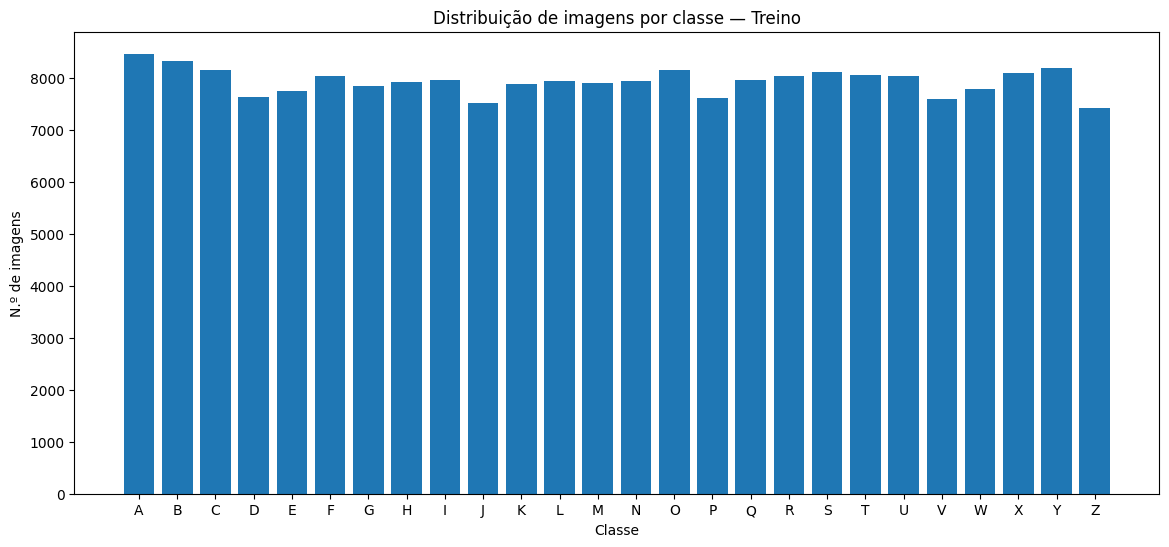

In [28]:
plt.figure(figsize=(14, 6))
plt.bar(train_counts['class'], train_counts['count'])
plt.title('Distribuição de imagens por classe — Treino')
plt.xlabel('Classe')
plt.ylabel('N.º de imagens')
plt.show()


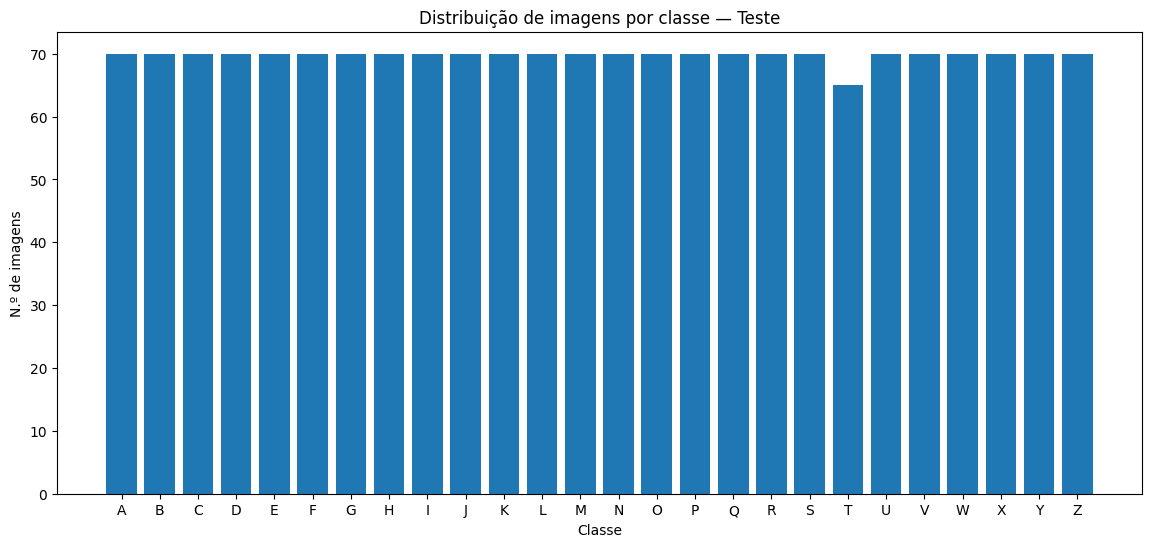

In [29]:
plt.figure(figsize=(14, 6))
plt.bar(test_counts['class'], test_counts['count'])
plt.title('Distribuição de imagens por classe — Teste')
plt.xlabel('Classe')
plt.ylabel('N.º de imagens')
plt.show()


In [30]:
compare_counts = train_counts[['class', 'count']].rename(columns={'count': 'train_count'}).merge(
    test_counts[['class', 'count']].rename(columns={'count': 'test_count'}),
    on='class',
    how='outer'
).fillna(0)

compare_counts['train_test_ratio'] = compare_counts.apply(
    lambda row: (row['train_count'] / row['test_count']) if row['test_count'] > 0 else np.inf,
    axis=1
)

display(compare_counts)


,class,train_count,test_count,train_test_ratio
0,A,8458,70,120.828571
1,B,8309,70,118.700000
2,C,8146,70,116.371429
3,D,7629,70,108.985714
4,E,7744,70,110.628571
5,F,8031,70,114.728571
6,G,7844,70,112.057143
7,H,7906,70,112.942857
8,I,7953,70,113.614286
9,J,7503,70,107.185714


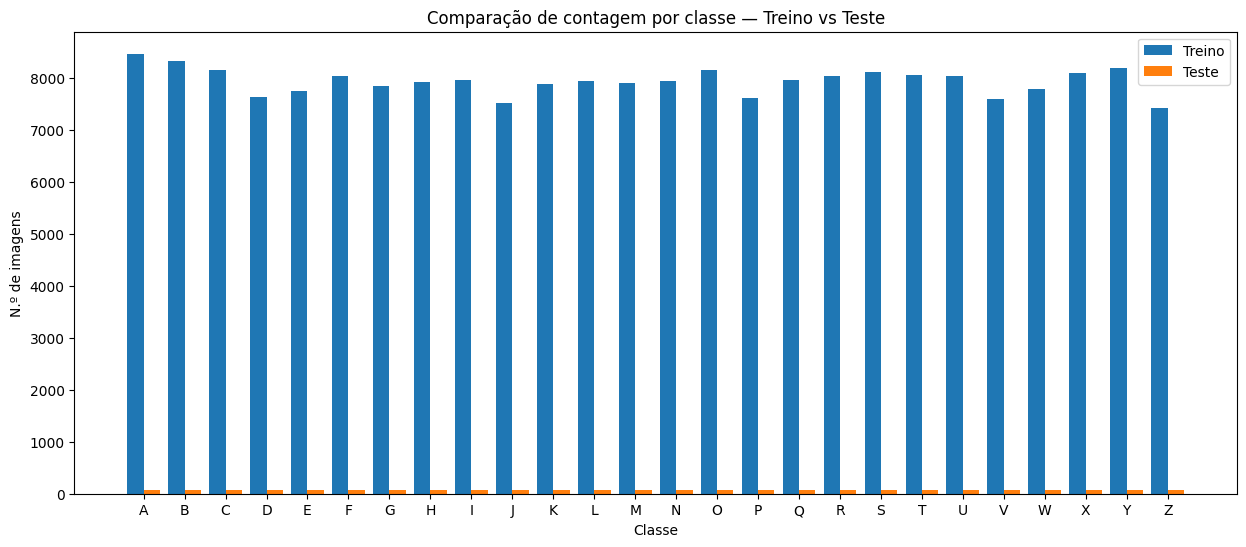

In [31]:
x = np.arange(len(compare_counts['class']))
width = 0.4

plt.figure(figsize=(15, 6))
plt.bar(x - width/2, compare_counts['train_count'], width=width, label='Treino')
plt.bar(x + width/2, compare_counts['test_count'], width=width, label='Teste')
plt.xticks(x, compare_counts['class'])
plt.title('Comparação de contagem por classe — Treino vs Teste')
plt.xlabel('Classe')
plt.ylabel('N.º de imagens')
plt.legend()
plt.show()


In [32]:
train_total = train_counts['count'].sum()
test_total = test_counts['count'].sum()

compare_percent = compare_counts.copy()
compare_percent['train_pct'] = 100 * compare_percent['train_count'] / train_total if train_total > 0 else 0
compare_percent['test_pct'] = 100 * compare_percent['test_count'] / test_total if test_total > 0 else 0
compare_percent['abs_pct_diff'] = (compare_percent['train_pct'] - compare_percent['test_pct']).abs()

display(compare_percent.sort_values('abs_pct_diff', ascending=False))


,class,train_count,test_count,train_test_ratio,train_pct,test_pct,abs_pct_diff
19,T,8054,65,123.907692,3.907110,3.581267,0.325843
25,Z,7410,70,105.857143,3.594697,3.856749,0.262053
0,A,8458,70,120.828571,4.103096,3.856749,0.246347
9,J,7503,70,107.185714,3.639812,3.856749,0.216937
1,B,8309,70,118.700000,4.030814,3.856749,0.174065
21,V,7597,70,108.528571,3.685413,3.856749,0.171336
15,P,7601,70,108.585714,3.687354,3.856749,0.169396
3,D,7629,70,108.985714,3.700937,3.856749,0.155813
24,Y,8178,70,116.828571,3.967264,3.856749,0.110515
4,E,7744,70,110.628571,3.756725,3.856749,0.100024


In [33]:
missing_in_train = [c for c in VALID_CLASSES if train_counts.loc[train_counts['class'] == c, 'count'].iloc[0] == 0]
missing_in_test = [c for c in VALID_CLASSES if test_counts.loc[test_counts['class'] == c, 'count'].iloc[0] == 0]

print('Classes em falta no treino:', missing_in_train if missing_in_train else 'Nenhuma')
print('Classes em falta no teste:', missing_in_test if missing_in_test else 'Nenhuma')


Classes em falta no treino: Nenhuma
Classes em falta no teste: Nenhuma


In [34]:
def image_size_summary(df, dataset_name):
    temp = df.dropna(subset=['width', 'height']).copy()
    if temp.empty:
        return pd.DataFrame([{
            'dataset': dataset_name,
            'n_valid_images': 0,
            'n_unique_sizes': 0,
            'most_common_size': None
        }])

    temp['size'] = temp['width'].astype(int).astype(str) + 'x' + temp['height'].astype(int).astype(str)
    most_common_size = temp['size'].mode().iloc[0] if not temp['size'].mode().empty else None

    return pd.DataFrame([{
        'dataset': dataset_name,
        'n_valid_images': len(temp),
        'n_unique_sizes': temp['size'].nunique(),
        'most_common_size': most_common_size
    }])

display(image_size_summary(train_df, 'train'))
display(image_size_summary(test_df, 'test'))


,dataset,n_valid_images,n_unique_sizes,most_common_size
0,train,206137,6,200x200


,dataset,n_valid_images,n_unique_sizes,most_common_size
0,test,1815,1,400x400


In [35]:
def top_image_sizes(df, top_n=15):
    temp = df.dropna(subset=['width', 'height']).copy()
    if temp.empty:
        return pd.DataFrame(columns=['size', 'count'])
    temp['size'] = temp['width'].astype(int).astype(str) + 'x' + temp['height'].astype(int).astype(str)
    return temp['size'].value_counts().head(top_n).rename_axis('size').reset_index(name='count')

print('Top tamanhos no treino:')
display(top_image_sizes(train_df))

print('Top tamanhos no teste:')
display(top_image_sizes(test_df))


Top tamanhos no treino:


,size,count
0,200x200,179541
1,400x400,18150
2,640x480,6680
3,1920x1920,1561
4,1280x720,201
5,150x200,4


Top tamanhos no teste:


,size,count
0,400x400,1815


In [36]:
broken_train = train_df[train_df['broken'] == True]
broken_test = test_df[test_df['broken'] == True]

print('Imagens corrompidas no treino:', len(broken_train))
print('Imagens corrompidas no teste:', len(broken_test))

if len(broken_train) > 0:
    display(broken_train.head())

if len(broken_test) > 0:
    display(broken_test.head())


Imagens corrompidas no treino: 0
Imagens corrompidas no teste: 0


In [37]:
def make_text_summary(summary_row, dataset_name):
    label = summary_row['balance_label']
    return (
        f'O conjunto {dataset_name} tem {int(summary_row["total_images"])} imagens distribuídas por ' 
        f'{int(summary_row["n_classes"])} classes. ' 
        f'A média por classe é {summary_row["mean_per_class"]:.2f}, com desvio padrão de ' 
        f'{summary_row["std_per_class"]:.2f}. ' 
        f'A classe com menos imagens tem {int(summary_row["min_class_count"])} e a classe com mais imagens ' 
        f'tem {int(summary_row["max_class_count"])}. ' 
        f'Isto indica: {label}.'
    )

train_row = summary_df[summary_df['dataset'] == 'train'].iloc[0]
test_row = summary_df[summary_df['dataset'] == 'test'].iloc[0]

print(make_text_summary(train_row, 'de treino'))
print()
print(make_text_summary(test_row, 'de teste'))


O conjunto de treino tem 206137 imagens distribuídas por 26 classes. A média por classe é 7928.35, com desvio padrão de 240.69. A classe com menos imagens tem 7410 e a classe com mais imagens tem 8458. Isto indica: Muito equilibrado.

O conjunto de teste tem 1815 imagens distribuídas por 26 classes. A média por classe é 69.81, com desvio padrão de 0.96. A classe com menos imagens tem 65 e a classe com mais imagens tem 70. Isto indica: Muito equilibrado.


In [38]:
output_dir = Path('outputs_dataset_analysis')
output_dir.mkdir(exist_ok=True)

train_df.to_csv(output_dir / 'train_images_detail.csv', index=False)
test_df.to_csv(output_dir / 'test_images_detail.csv', index=False)
train_counts.to_csv(output_dir / 'train_class_counts.csv', index=False)
test_counts.to_csv(output_dir / 'test_class_counts.csv', index=False)
compare_counts.to_csv(output_dir / 'train_test_class_comparison.csv', index=False)
compare_percent.to_csv(output_dir / 'train_test_percentage_comparison.csv', index=False)
summary_df.to_csv(output_dir / 'dataset_balance_summary.csv', index=False)

print('Ficheiros exportados para:', output_dir.resolve())


Ficheiros exportados para: /home/tomas/MIA/1ANO/2SEM/SA/SA-25_26/TrabalhoPratico/outputs_dataset_analysis
